In [1]:
import sys
from pathlib import Path

# Make `src` importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)

In [2]:
turns = pd.read_parquet(config.MATHDIAL_PROCESSED_TURNS_FILE)
print(f"Total turns: {len(turns)}")
print(f"Total dialogues: {turns['qid'].nunique()}")
turns.head()

Total turns: 27508
Total dialogues: 1035


,qid,question,ground_truth,student_incorrect_solution,student_profile,teacher_described_confusion,self_correctness,turn_idx,speaker,move,text,context_window
0,5000012,"Nancy is filling an aquarium for her fish. She fills it halfway and goes to answer the door. While she's gone, her c...","First calculate the volume of the aquarium by multiplying its length, width and height: 4 ft * 6 ft * 3 ft = 72 cubi...","The aquarium has a volume of 4 x 6 x 3 = 72 cubic feet.\nWhen Nancy fills it halfway, she fills it with 72/2 = 36 cu...",Steven is a 7th grade student. He has difficulty determining which pieces of information are relevant and which are ...,He added a step after completing the problem.,Yes,0,teacher,probing,"Steven, If you had 4 of something and tripled that amount, how much would you have?",
1,5000012,"Nancy is filling an aquarium for her fish. She fills it halfway and goes to answer the door. While she's gone, her c...","First calculate the volume of the aquarium by multiplying its length, width and height: 4 ft * 6 ft * 3 ft = 72 cubi...","The aquarium has a volume of 4 x 6 x 3 = 72 cubic feet.\nWhen Nancy fills it halfway, she fills it with 72/2 = 36 cu...",Steven is a 7th grade student. He has difficulty determining which pieces of information are relevant and which are ...,He added a step after completing the problem.,Yes,2,teacher,probing,"So if Nancy triples the 18 cubic feet of water, how much would she have?","Teacher: Steven, If you had 4 of something and tripled that amount, how much would you have? || Teacher: So if Nancy..."
2,5000012,"Nancy is filling an aquarium for her fish. She fills it halfway and goes to answer the door. While she's gone, her c...","First calculate the volume of the aquarium by multiplying its length, width and height: 4 ft * 6 ft * 3 ft = 72 cubi...","The aquarium has a volume of 4 x 6 x 3 = 72 cubic feet.\nWhen Nancy fills it halfway, she fills it with 72/2 = 36 cu...",Steven is a 7th grade student. He has difficulty determining which pieces of information are relevant and which are ...,He added a step after completing the problem.,Yes,4,teacher,generic,Exactly correct!,"Teacher: Steven, If you had 4 of something and tripled that amount, how much would you have? || Teacher: So if Nancy..."
3,5000084,John is very unfit and decides to work up to doing a push-up. He trains 5 days a week for them and starts with wall...,He needs to do 15*3=45 progressions\nThat will take 45/5=9 weeks\n 9,"To get to 15 reps, John will take 15 - 1 = 14 days.\nTo get to high elevation push-ups, he will take 15 + (15-1) = 2...",Stephanie is a 7th grade student. She has difficulty determining which pieces of information are relevant and which ...,She became fixated on a wrong calculation and couldn't let go.,No,0,teacher,probing,"Stephanie, How many days will it take to do one step, if John adds one pushup per day?",
4,5000084,John is very unfit and decides to work up to doing a push-up. He trains 5 days a week for them and starts with wall...,He needs to do 15*3=45 progressions\nThat will take 45/5=9 weeks\n 9,"To get to 15 reps, John will take 15 - 1 = 14 days.\nTo get to high elevation push-ups, he will take 15 + (15-1) = 2...",Stephanie is a 7th grade student. She has difficulty determining which pieces of information are relevant and which ...,She became fixated on a wrong calculation and couldn't let go.,No,1,student,None,"It will take one day to do one step, since John adds one pushup per day.","Teacher: Stephanie, How many days will it take to do one step, if John adds one pushup per day?"


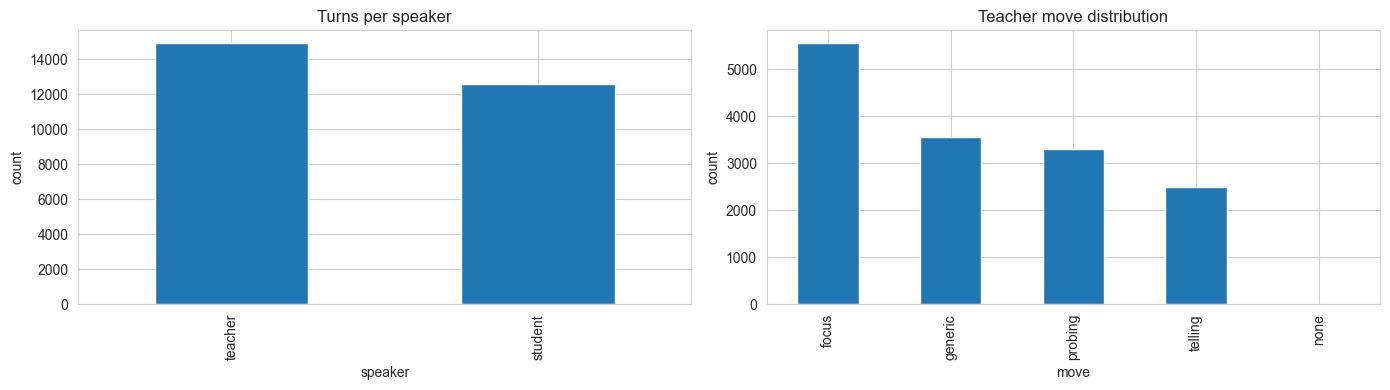

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

turns["speaker"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Turns per speaker")
axes[0].set_ylabel("count")

teacher_moves = turns[turns["speaker"] == "teacher"]["move"].fillna("none")
teacher_moves.value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Teacher move distribution")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig(config.RESULTS_DIR / "ped_prm_eval" / "01_speaker_move_distribution.png", dpi=120)
plt.show()

Mean turns/dialogue: 26.6
Median: 24
Min/Max: 3 / 86


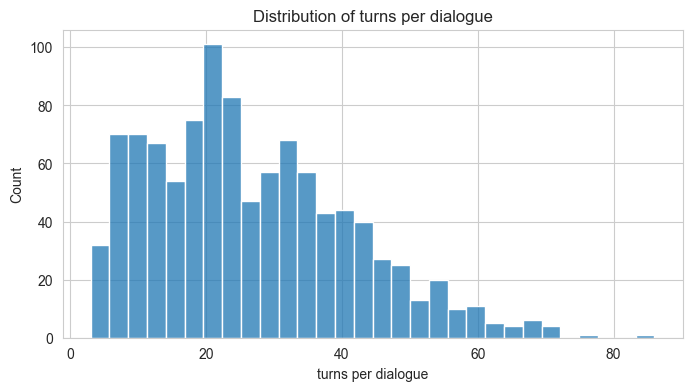

In [4]:
turns_per_dialogue = turns.groupby("qid").size()
print(f"Mean turns/dialogue: {turns_per_dialogue.mean():.1f}")
print(f"Median: {turns_per_dialogue.median():.0f}")
print(f"Min/Max: {turns_per_dialogue.min()} / {turns_per_dialogue.max()}")

plt.figure(figsize=(8, 4))
sns.histplot(turns_per_dialogue, bins=30)
plt.title("Distribution of turns per dialogue")
plt.xlabel("turns per dialogue")
plt.savefig(config.RESULTS_DIR / "ped_prm_eval" / "02_turns_per_dialogue.png", dpi=120)
plt.show()

In [5]:
sample_qid = turns["qid"].iloc[0]
sample = turns[turns["qid"] == sample_qid].sort_values("turn_idx")
print(f"=== Dialogue {sample_qid} ===")
print(f"Question: {sample.iloc[0]['question']}\n")
print(f"Student incorrect solution: {sample.iloc[0]['student_incorrect_solution']}\n")
print(f"Outcome: {sample.iloc[0]['self_correctness']}\n")
print("--- Conversation ---")
for _, row in sample.iterrows():
    move_tag = f"[{row['move']}]" if row['move'] else ""
    print(f"{row['speaker'].upper()} {move_tag}: {row['text']}\n")

=== Dialogue 5000012 ===
Question: Nancy is filling an aquarium for her fish. She fills it halfway and goes to answer the door. While she's gone, her cat knocks the aquarium over and spills half the water in it. Then Nancy comes back and triples the amount of water in the aquarium. If the aquarium is 4 feet long, 6 feet wide, and 3 feet high, how many cubic feet of water are in the aquarium?

Student incorrect solution: The aquarium has a volume of 4 x 6 x 3 = 72 cubic feet.
When Nancy fills it halfway, she fills it with 72/2 = 36 cubic feet of water.
When the cat spills half of that, there are 36/2 = 18 cubic feet of water left.
When Nancy triples that amount, she adds 18 x 3 = 54 cubic feet of water.
The aquarium now has 18 + 54 = 72 cubic feet of water.
 72

Outcome: Yes

--- Conversation ---
TEACHER [probing]: Steven, If you had 4 of something and tripled that amount, how much would you have?

TEACHER [generic]: Hi Ayisha, tell me your solution

TEACHER [generic]: Hi Jian, can you 

self_correctness
Yes                                    781
Yes, but I had to reveal the answer    138
No                                     113
missing                                  3
Name: count, dtype: int64


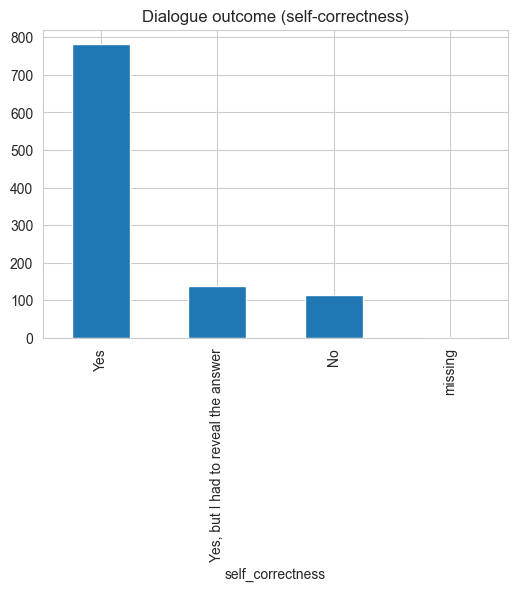

In [6]:
outcomes = turns.drop_duplicates("qid")["self_correctness"].fillna("missing")
print(outcomes.value_counts())

plt.figure(figsize=(6, 4))
outcomes.value_counts().plot(kind="bar")
plt.title("Dialogue outcome (self-correctness)")
plt.savefig(config.RESULTS_DIR / "ped_prm_eval" / "03_outcomes.png", dpi=120)
plt.show()